# KoGPT2 성능 개선 프로젝트: 데이터 정제 → SFT → RM 재정렬


- 기존 KoChatGPT SFT 데이터를 정제하고 새로 만든 한국어 지시문 데이터를 합칩니다.
- 기존 KoGPT2와 LoRA-SFT 모델을 같은 평가셋·같은 생성 전략으로 비교합니다.
- RM(Reward Model)은 답을 생성하는 모델이 아니라 **두 답변 중 더 좋은 답을 고르는 모델**로 학습합니다.
- 마지막에 SFT 후보를 RM으로 재정렬해 SFT 단독과 SFT+RM을 정량·정성 비교합니다.

> 권장 환경: Google Colab GPU(T4 이상). `런타임 → 모두 실행` 순서로 실행하면 됩니다.  
> 기본값은 수업 시간 안에 끝나는 `FAST_MODE=True`예요. 최종 보고서용 실험은 `False`로 바꿔 표본 수와 epoch을 늘려 주세요.

## 1. CUDA용 PyTorch와 필요한 패키지 설치

RTX 3090에서는 CUDA 지원 PyTorch가 설치되어 있어야 해요. 아래 셀은 Windows/Linux용 CUDA 12.6 wheel을 설치합니다. **처음 설치한 뒤 커널을 재시작하고 위에서부터 다시 실행**해 주세요. NVIDIA 드라이버는 미리 설치되어 있어야 합니다.

> 이미 `torch.cuda.is_available() == True`라면 첫 번째 설치 명령은 다시 실행하지 않아도 됩니다.

In [ ]:
# [셀 설명] RTX 3090에서 사용할 CUDA PyTorch와 학습 패키지를 설치한다.
# 첫 실행 후에는 커널을 재시작해야 새 PyTorch가 현재 커널에 반영된다.
# RTX 3090용 CUDA PyTorch 설치
%pip install -q --upgrade "torch==2.7.0" "torchvision==0.22.0" "torchaudio==2.7.0" --index-url https://download.pytorch.org/whl/cu126

# 학습 및 평가 패키지 설치
%pip install -q "transformers==4.46.3" "datasets==3.2.0" "peft==0.14.0" \
  "accelerate==1.2.1" "rouge-score==0.1.2" "sacrebleu==2.4.3" \
  "sentencepiece==0.2.0" "scikit-learn>=1.3" "seaborn>=0.13"

## 2. GPU 진단과 CPU fallback 최적화

RTX 3090이 정상 인식되면 CUDA·FP16·TF32를 켭니다. GPU가 잡히지 않는 경우에도 멈추지는 않고, 16코어/32스레드 CPU에 맞춰 PyTorch 연산 스레드를 설정해 계속 실행합니다. Windows 노트북에서는 DataLoader 멀티프로세싱이 멈추는 경우가 있어 worker는 안전하게 0으로 두고, 실제 행렬 연산에 물리 코어 16개를 사용합니다.

In [1]:
# [셀 설명] 라이브러리를 불러오고 GPU/CPU 실행 환경을 설정한다.
# GPU가 있으면 CUDA 최적화를 켜고, 없으면 16코어 CPU 설정으로 전환한다.
# 표준 라이브러리와 실험에 필요한 패키지를 불러온다.
import os, gc, json, math, random, re, hashlib, unicodedata, warnings
import platform, subprocess, shutil
from pathlib import Path

# CUDA 메모리 파편화를 줄인다.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# 로컬에서 직접 만든 Trainer 체크포인트의 RNG 상태를 재개한다.
os.environ.setdefault("TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "16")
os.environ.setdefault("MKL_NUM_THREADS", "16")

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, load_dataset
from peft import (
    LoraConfig, TaskType, get_peft_model,
    get_peft_model_state_dict, set_peft_model_state_dict,
)
from rouge_score import rouge_scorer
from sacrebleu.metrics import CHRF
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM, AutoModelForSequenceClassification, AutoTokenizer,
    DataCollatorWithPadding, EarlyStoppingCallback, Trainer, TrainingArguments,
    set_seed,
)
from transformers.trainer_utils import get_last_checkpoint

# seed를 고정해 데이터 분할과 sampling의 재현성을 높인다.
warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# 16코어/32스레드 CPU에 맞춘 설정
# 논리 프로세서 수를 읽고 실제 행렬 연산에는 물리 코어 수준의 스레드를 사용한다.
LOGICAL_CPUS = os.cpu_count() or 32
CPU_COMPUTE_THREADS = min(16, LOGICAL_CPUS)
CPU_INTEROP_THREADS = min(4, max(1, LOGICAL_CPUS // 8))
torch.set_num_threads(CPU_COMPUTE_THREADS)
try:
    torch.set_num_interop_threads(CPU_INTEROP_THREADS)
except RuntimeError:
    pass  # 이미 병렬 연산이 시작된 커널에서는 변경할 수 없다.

# CUDA 사용 가능 여부에 따라 학습 장치와 기본 dtype을 결정한다.
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")
DTYPE = torch.float16 if USE_CUDA else torch.float32

# Windows/Jupyter에서는 worker=0이 가장 안정적이다.
DATALOADER_WORKERS = 0 if os.name == "nt" else min(8, max(1, LOGICAL_CPUS // 4))
DATASET_NUM_PROC = 1 if os.name == "nt" else min(8, max(1, LOGICAL_CPUS // 4))

print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("device:", DEVICE)
print("CPU logical/compute/inter-op:", LOGICAL_CPUS, CPU_COMPUTE_THREADS, CPU_INTEROP_THREADS)

# RTX 3090이 감지되면 TF32와 cuDNN benchmark를 활성화한다.
if USE_CUDA:
    torch.cuda.set_device(0)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    props = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
    # 작은 행렬곱으로 실제 CUDA 연산까지 확인한다.
    smoke = torch.randn(1024, 1024, device=DEVICE)
    smoke = smoke @ smoke
    torch.cuda.synchronize()
    print("CUDA smoke test:", smoke.device, tuple(smoke.shape))
    del smoke
    torch.cuda.empty_cache()
    print("CUDA 사용 준비 완료")
else:
    print("\n[경고] CUDA GPU를 찾지 못해 CPU로 실행합니다.")
    try:
        smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
        print(smi.stdout[:2000] if smi.returncode == 0 else smi.stderr[:1000])
    except Exception:
        print("nvidia-smi도 실행되지 않습니다. NVIDIA 드라이버를 확인하세요.")
    if torch.version.cuda is None:
        print("현재 PyTorch가 CPU 빌드입니다. 설치 셀을 실행하고 커널을 재시작하세요.")

C:\Users\김민\Desktop\aiffel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.7.0+cu126
PyTorch CUDA build: 12.6
device: cuda:0
CPU logical/compute/inter-op: 32 16 4
GPU: NVIDIA GeForce RTX 3090
VRAM: 24.0 GB
CUDA smoke test: cuda:0 (1024, 1024)
CUDA 사용 준비 완료


## 3. 50 epoch와 조기 종료 설정

SFT와 RM 모두 최대 50 epoch까지 학습하되 validation 성능이 5번 연속 좋아지지 않으면 일찍 멈춥니다. GPU에서는 전체 실험 크기를 사용하고, CPU fallback에서는 실행 시간을 줄이기 위해 표본 수만 축소합니다. epoch 상한은 CPU에서도 50으로 동일합니다.

In [2]:
# [셀 설명] 데이터 크기, epoch, batch size 등 실험 조건을 한곳에서 관리한다.
# GPU에서는 전체 설정을, CPU에서는 실행 가능한 축소 설정을 자동 선택한다.
# 비교 기준이 되는 한국어 생성 모델을 지정한다.
MODEL_NAME = "skt/kogpt2-base-v2"
FAST_MODE = not USE_CUDA

# 학습과 평가에서 공통으로 사용할 하이퍼파라미터다.
CFG = {
    "sft_max_rows": 1200 if FAST_MODE else 6000,
    "rm_max_pairs": 1200 if FAST_MODE else 6000,
    "sft_epochs": 50,
    "rm_epochs": 50,
    "early_stopping_patience": 5,
    "early_stopping_threshold": 1e-4,
    "generation_eval_rows": 24 if FAST_MODE else 100,
    "max_length": 256,
    "max_new_tokens": 64,
    "sft_batch_size": 16 if USE_CUDA else 4,
    "rm_batch_size": 16 if USE_CUDA else 4,
    "resume_sft": True,
}
print("실행 모드:", "RTX 3090 GPU" if USE_CUDA else "16-core CPU fallback")
CFG

실행 모드: RTX 3090 GPU


{'sft_max_rows': 6000,
 'rm_max_pairs': 6000,
 'sft_epochs': 50,
 'rm_epochs': 50,
 'early_stopping_patience': 5,
 'early_stopping_threshold': 0.0001,
 'generation_eval_rows': 100,
 'max_length': 256,
 'max_new_tokens': 64,
 'sft_batch_size': 16,
 'rm_batch_size': 16,
 'resume_sft': True}

## 4. 기존 데이터와 새 데이터 불러오기

기존 데이터는 샘플과 같은 KoChatGPT SFT/RM 파일을 사용해요. 여기에 직접 수집·작성한 생활형 한국어 지시문을 추가해서, 새 데이터가 어떤 영향을 주는지도 추적할 수 있게 `source` 열을 붙였습니다.

In [3]:
# [셀 설명] 기존 KoChatGPT 데이터와 새로 작성한 한국어 데이터를 준비한다.
# 모든 데이터에는 출처를 표시해 정제 후에도 데이터 구성을 확인할 수 있게 한다.
import requests

BASE_URL = "https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt"

# JSON 배열과 JSONL 형식을 모두 처리한다.
def load_json_url(url):
    # JSON 배열과 JSONL을 모두 안전하게 읽는다.
    text = requests.get(url, timeout=60).content.decode("utf-8-sig")
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return [json.loads(line) for line in text.splitlines() if line.strip()]

# SFT와 RM 원본 데이터를 각각 내려받는다.
sft_raw = load_json_url(f"{BASE_URL}/kochatgpt_1_SFT.jsonl")
rm_raw = load_json_url(f"{BASE_URL}/kochatgpt_2_RM.jsonl")
print("기존 SFT 원본:", len(sft_raw), "| 기존 RM 원본:", len(rm_raw))

# 팀이 새로 수집·작성했다고 가정한 생활형 한국어 예시다.
# 부족한 생활형·안전형 질문을 직접 작성해 신규 데이터로 추가한다.
NEW_CURATED = [
    ("회의 시작을 정중하게 알리는 한 문장을 써 줘.", "안녕하세요. 지금부터 회의를 시작하겠습니다. 참석해 주셔서 감사합니다."),
    ("김치볶음밥을 만드는 순서를 세 단계로 알려 줘.", "1. 김치와 재료를 잘게 썹니다. 2. 팬에 재료와 밥을 볶습니다. 3. 간을 맞춘 뒤 그릇에 담습니다."),
    ("비밀번호를 안전하게 관리하는 방법 두 가지를 알려 줘.", "사이트마다 다른 긴 비밀번호를 사용하고, 가능하면 비밀번호 관리자와 2단계 인증을 함께 사용하세요."),
    ("친구의 합격을 축하하는 짧은 메시지를 써 줘.", "합격 정말 축하해! 노력한 만큼 좋은 결과가 나와서 나도 무척 기뻐."),
    ("재활용할 때 종이컵을 어떻게 버려야 해?", "내용물을 비우고 깨끗이 헹군 뒤 지역 분리배출 기준을 확인하세요. 코팅된 종이컵은 일반 종이와 분류가 다를 수 있습니다."),
    ("감기에 항생제를 먹어도 되는지 설명해 줘.", "감기는 대부분 바이러스성이라 항생제가 효과가 없습니다. 항생제는 의사의 진단과 처방에 따라 복용해야 합니다."),
    ("서울 여행 하루 일정을 간단히 추천해 줘.", "오전에는 경복궁을 둘러보고, 점심은 인사동에서 먹은 뒤, 오후에는 청계천과 남산을 방문해 보세요."),
    ("파이썬 리스트와 튜플의 차이를 한 문장으로 설명해 줘.", "리스트는 생성 후 값을 바꿀 수 있지만 튜플은 원칙적으로 값을 바꿀 수 없습니다."),
    ("택배가 늦어서 문의하는 정중한 문장을 써 줘.", "안녕하세요. 주문한 상품의 배송이 지연되어 현재 배송 상태와 예상 도착일을 확인 부탁드립니다."),
    ("물 절약 방법을 세 가지 알려 줘.", "양치할 때 물을 잠그고, 짧게 샤워하며, 세탁기는 빨래를 모아 한 번에 사용해 보세요."),
    ("운동 전에 준비운동이 필요한 이유는 뭐야?", "준비운동은 체온과 혈류를 높여 몸을 움직임에 적응시키고 부상 위험을 줄이는 데 도움을 줍니다."),
    ("사과문에 꼭 들어가야 할 내용을 알려 줘.", "잘못한 사실, 상대가 받은 영향에 대한 공감, 책임 인정, 재발 방지 계획을 구체적으로 담는 것이 좋습니다."),
    ("카페인을 늦은 밤에 피해야 하는 이유를 설명해 줘.", "카페인은 각성 효과가 오래 지속되어 잠드는 시간을 늦추고 수면의 질을 떨어뜨릴 수 있습니다."),
    ("중고 거래 장소를 고를 때 주의할 점은?", "사람이 많고 CCTV가 있는 밝은 공공장소를 선택하고, 가능하면 낮 시간에 거래하세요."),
    ("면접 후 감사 메일 제목을 추천해 줘.", "[면접 감사] 지원자 홍길동입니다"),
    ("분수 1/2과 1/3 중 어느 것이 큰지 설명해 줘.", "분모를 6으로 맞추면 1/2은 3/6, 1/3은 2/6이므로 1/2이 더 큽니다."),
    ("온라인 기사 내용을 공유할 때 확인할 점은?", "작성 날짜, 출처의 신뢰성, 근거 자료, 다른 매체의 교차 보도를 확인한 뒤 공유하세요."),
    ("반려견에게 초콜릿을 줘도 돼?", "안 됩니다. 초콜릿 성분은 개에게 중독을 일으킬 수 있으므로 먹었다면 양과 종류를 확인해 즉시 동물병원에 문의하세요."),
    ("집중이 안 될 때 할 수 있는 간단한 방법을 알려 줘.", "할 일을 25분 단위로 나누고 알림을 끈 뒤, 한 번에 한 가지 일만 해 보세요."),
    ("개인정보가 담긴 파일을 이메일로 보낼 때 주의점은?", "수신자를 다시 확인하고 파일을 암호화하며, 비밀번호는 별도 채널로 전달하세요."),
]

new_df = pd.DataFrame(NEW_CURATED, columns=["prompt", "completion"])
new_df["source"] = "new_curated"
new_df.head(3)

기존 SFT 원본: 12000 | 기존 RM 원본: 10220


,prompt,completion,source
0,회의 시작을 정중하게 알리는 한 문장을 써 줘.,안녕하세요. 지금부터 회의를 시작하겠습니다. 참석해 주셔서 감사합니다.,new_curated
1,김치볶음밥을 만드는 순서를 세 단계로 알려 줘.,1. 김치와 재료를 잘게 썹니다. 2. 팬에 재료와 밥을 볶습니다. 3. 간을 맞춘...,new_curated
2,비밀번호를 안전하게 관리하는 방법 두 가지를 알려 줘.,"사이트마다 다른 긴 비밀번호를 사용하고, 가능하면 비밀번호 관리자와 2단계 인증을 ...",new_curated


## 5. 데이터 정제와 누수 방지

여기서 빈 문장, 지나치게 짧거나 긴 답, URL·HTML, 중복 문장을 제거합니다. 그다음 **정제 후에** prompt 단위로 train/validation/test를 나눠 같은 질문이 양쪽에 들어가는 누수를 막을게요.

In [4]:
# [셀 설명] 문장을 정규화하고 중복·이상치를 제거한 뒤 데이터셋을 분리한다.
# 같은 질문이 train/validation/test에 동시에 들어가지 않도록 그룹 단위로 나눈다.
# 표기 차이를 줄이기 위해 유니코드와 연속 공백을 정규화한다.
def clean_text(x):
    # 유니코드와 공백을 정규화하고 HTML/URL을 제거한다.
    x = unicodedata.normalize("NFKC", str(x))
    x = re.sub(r"<[^>]+>|https?://\S+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

# 한글 비율이 지나치게 낮은 문장을 찾기 위한 보조 함수다.
def korean_ratio(text):
    # 문자 중 한글이 차지하는 비율을 계산한다.
    chars = [c for c in text if not c.isspace()]
    return sum("가" <= c <= "힣" for c in chars) / max(1, len(chars))

# 원본 SFT 레코드를 분석하기 쉬운 DataFrame 형태로 바꾼다.
old_df = pd.DataFrame({
    "prompt": [x.get("prompt", "") for x in sft_raw],
    "completion": [x.get("completion", "") for x in sft_raw],
    "source": "kochatgpt_original",
})

before = len(old_df) + len(new_df)
# 기존 데이터와 신규 데이터를 합친 뒤 품질 조건을 적용한다.
sft_df = pd.concat([old_df, new_df], ignore_index=True)
sft_df[["prompt", "completion"]] = sft_df[["prompt", "completion"]].apply(
    lambda col: col.map(clean_text)
)
sft_df = sft_df[
    sft_df["prompt"].str.len().between(4, 300)
    & sft_df["completion"].str.len().between(8, 800)
    & ((sft_df["prompt"] + sft_df["completion"]).map(korean_ratio) >= 0.10)
].copy()
sft_df["dedup_key"] = (sft_df["prompt"] + "\n" + sft_df["completion"]).map(
    lambda x: hashlib.sha256(x.encode()).hexdigest()
)
sft_df = sft_df.drop_duplicates("dedup_key").drop(columns="dedup_key")

# 원본이 너무 크면 seed를 고정해 표본을 뽑는다. 새 데이터는 모두 유지한다.
old_clean = sft_df[sft_df.source == "kochatgpt_original"]
old_clean = old_clean.sample(min(len(old_clean), CFG["sft_max_rows"]), random_state=SEED)
# 기존 데이터와 신규 데이터를 합친 뒤 품질 조건을 적용한다.
sft_df = pd.concat([old_clean, sft_df[sft_df.source == "new_curated"]], ignore_index=True)

# 같은 질문의 여러 답변이 서로 다른 split에 섞이지 않게 group split한다.
# 첫 번째 분할에서 train 80%와 임시 데이터 20%를 만든다.
outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, temp_idx = next(outer.split(sft_df, groups=sft_df.prompt))
train_df, temp_df = sft_df.iloc[train_idx].copy(), sft_df.iloc[temp_idx].copy()
# 임시 데이터를 반으로 나눠 validation 10%와 test 10%를 만든다.
inner = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
valid_idx, test_idx = next(inner.split(temp_df, groups=temp_df.prompt))
valid_df, test_df = temp_df.iloc[valid_idx].copy(), temp_df.iloc[test_idx].copy()

# 질문 중복이 split 사이에 없는지 검사한다.
assert set(train_df.prompt).isdisjoint(valid_df.prompt)
assert set(train_df.prompt).isdisjoint(test_df.prompt)
assert set(valid_df.prompt).isdisjoint(test_df.prompt)

cleaning_report = pd.DataFrame({
    "항목": ["정제 전", "정제·중복제거 후 사용", "train", "validation", "test", "새 데이터"],
    "개수": [before, len(sft_df), len(train_df), len(valid_df), len(test_df), (sft_df.source == "new_curated").sum()]
})
cleaning_report

,항목,개수
0,정제 전,12020
1,정제·중복제거 후 사용,6020
2,train,4815
3,validation,602
4,test,603
5,새 데이터,20


## 6. 토크나이저와 프롬프트 형식

질문과 답변의 경계를 일정하게 만들면 모델이 “어디부터 답해야 하는지” 배우기 쉬워요. KoGPT2에는 별도 pad token이 없어서 eos token을 pad로 안전하게 사용합니다.

In [5]:
# [셀 설명] KoGPT2 토크나이저와 질문/답변 프롬프트 형식을 정의한다.
# 토크나이저 크기가 달라졌을 때 모델 임베딩도 같은 크기로 맞춘다.
# KoGPT2 전용 토크나이저를 불러온다.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = CFG["max_length"]

# 모든 데이터와 추론에 동일한 질문/답변 구분 형식을 사용한다.
def make_prompt(question):
    return f"### 질문:\n{clean_text(question)}\n\n### 답변:\n"

# 추가된 token이 있어도 embedding index 오류가 나지 않게 크기를 정렬한다.
def align_model_vocab(model):
    # 토크나이저의 추가 토큰 수와 모델 임베딩 크기를 맞춘다.
    model_vocab = model.get_input_embeddings().num_embeddings
    tokenizer_vocab = len(tokenizer)
    if model_vocab != tokenizer_vocab:
        model.resize_token_embeddings(tokenizer_vocab)
        print(f"임베딩 크기 조정: {model_vocab} -> {tokenizer_vocab}")
    model.config.pad_token_id = tokenizer.pad_token_id
    return model

print(make_prompt("재활용 방법을 알려 줘."))

### 질문:
재활용 방법을 알려 줘.

### 답변:



## 7. SFT용 토큰화

중요한 부분이에요. 질문 토큰까지 정답으로 학습시키지 않고, **답변 토큰에만 loss가 생기도록** 질문 부분 label을 `-100`으로 가립니다.

In [6]:
# [셀 설명] SFT 입력을 토큰화하고 답변 부분에만 loss가 적용되도록 label을 만든다.
# 배치마다 길이가 다른 문장은 collator가 가장 긴 문장에 맞춰 padding한다.
# 질문과 정답을 연결한 뒤 최대 길이 안에서 토큰화한다.
def tokenize_sft(example):
    prompt = make_prompt(example["prompt"])
    full = prompt + example["completion"] + tokenizer.eos_token
    full_ids = tokenizer(full, truncation=True, max_length=CFG["max_length"])["input_ids"]
    prompt_ids = tokenizer(prompt, truncation=True, max_length=CFG["max_length"])["input_ids"]
    # 질문 영역은 -100으로 가려 답변 토큰에만 loss를 계산한다.
    labels = full_ids.copy()
    labels[:min(len(prompt_ids), len(labels))] = [-100] * min(len(prompt_ids), len(labels))
    return {"input_ids": full_ids, "attention_mask": [1] * len(full_ids), "labels": labels}

# 서로 다른 길이의 샘플을 하나의 tensor batch로 묶는다.
class SFTCollator:
    def __init__(self, pad_id): self.pad_id = pad_id
    def __call__(self, batch):
        max_len = max(len(x["input_ids"]) for x in batch)
        def pad(seq, value): return seq + [value] * (max_len - len(seq))
        return {
            "input_ids": torch.tensor([pad(x["input_ids"], self.pad_id) for x in batch]),
            "attention_mask": torch.tensor([pad(x["attention_mask"], 0) for x in batch]),
            "labels": torch.tensor([pad(x["labels"], -100) for x in batch]),
        }

# DataFrame을 Trainer가 읽을 수 있는 Hugging Face Dataset으로 변환한다.
train_ds = Dataset.from_pandas(train_df[["prompt", "completion"]], preserve_index=False).map(tokenize_sft, num_proc=DATASET_NUM_PROC)
valid_ds = Dataset.from_pandas(valid_df[["prompt", "completion"]], preserve_index=False).map(tokenize_sft, num_proc=DATASET_NUM_PROC)
print(train_ds[0])

Map: 100%|██████████| 602/602 [00:00<00:00, 4048.55 examples/s]

{'prompt': '핸드폰 요금 많이 나옴', 'completion': "'핸드폰 요금이 많이 나올 수 있는 이유는 여러 가지가 있을 수 있습니다. 아래는 대표적인 이유들입니다.\\n\\n1. 데이터 사용량\\n\\n핸드폰을 이용하여 인터넷을 자주 이용하거나, 영상 시청, 게임 등 데이터를 많이 소비하는 경우 요금이 많이 나올 수 있습니다. 이 경우에는 사용량을 줄이거나, 요금제를 변경하는 등의 대처가 필요합니다.\\n\\n2. 로밍\\n\\n여행 중에 해외에서 핸드폰을 사용하는 경우 로밍 요금이 많이 나올 수 있습니다. 이 경우에는 로밍 요금이 비싼 통신사나, 해외에서와 연결이 잘 되는 무선망을 이용하는 것이 좋습니다.\\n\\n3. 부가서비스\\n\\n핸드폰 제공업체가 제공하는 다양한 부가서비스를 이용하면 요금이 크게 올라갈 수 있습니다. 이 경우에는 필요한 서비스만 이용하고, 불필요한 부가서비스는 중단하는 것이 좋습니다.\\n\\n4. 요금제 선택\\n\\n간단한 통화와 문자 메시지만을 이용하는 경우에는 기본 요금제를 선택하는 것이 좋으나, 인터넷 사용이 많거나, 무제한 통화, 문자메시지를 이용하는 등 필요에 따라 요금제를 변경하는 것이 좋습니다.\\n\\n요약하면, 핸드폰 요금을 줄이기 위해서는 데이터 사용량을 줄이고, 로밍 요금을 줄이는 등의 방법을 이용하는 것이 좋습니다. 또한, 요금제 선택 역시 중요한 부분이니, 필요에 따라 요금제를 변경하는 것이 좋습니다.", 'input_ids': [739, 378, 378, 378, 24454, 401, 375, 8713, 7281, 8660, 50635, 9564, 9063, 8061, 375, 375, 378, 378, 378, 12817, 7643, 401, 375, 382, 8713, 7281, 8660, 9242, 17295, 9564, 24411, 9025, 9080, 13404, 9311, 14679, 9846, 9025, 32987, 39789, 10529, 10175, 7285, 21154,

## 8. 기존 KoGPT2의 validation loss 측정

SFT 전 모델의 기준점을 먼저 저장합니다. 이 값을 남겨야 “좋아 보인다”가 아니라 같은 validation 데이터에서 loss와 perplexity가 얼마나 변했는지 말할 수 있어요.

In [7]:
# [셀 설명] 학습 전 KoGPT2의 validation loss와 perplexity를 기준선으로 측정한다.
# 입력 토큰이 모델 vocabulary 범위를 벗어나는지도 배치마다 확인한다.
# 아직 SFT하지 않은 원본 KoGPT2를 기준 모델로 불러온다.
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
base_model = align_model_vocab(base_model).to(DEVICE)

# 평가 중에는 gradient를 만들지 않아 메모리와 시간을 절약한다.
@torch.inference_mode()
def mean_eval_loss(model, dataset, batch_size=8):
    loader = DataLoader(
        dataset, batch_size=batch_size, collate_fn=SFTCollator(tokenizer.pad_token_id),
        num_workers=DATALOADER_WORKERS, pin_memory=USE_CUDA,
        persistent_workers=(DATALOADER_WORKERS > 0),
    )
    losses = []
    model.eval()
    # validation batch별 loss를 모아 전체 평균을 계산한다.
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        max_id = int(batch["input_ids"].max())
        vocab_size = model.get_input_embeddings().num_embeddings
        if max_id >= vocab_size:
            raise RuntimeError(
                f"input_id={max_id}, embedding_size={vocab_size}. "
                "토크나이저/SFT 데이터셋 생성 셀부터 다시 실행해 주세요."
            )
        losses.append(model(**batch).loss.item())
    return float(np.mean(losses))

base_val_loss = mean_eval_loss(base_model, valid_ds)
print({"base_val_loss": base_val_loss, "base_perplexity": math.exp(min(base_val_loss, 20))})

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


임베딩 크기 조정: 51200 -> 51201
{'base_val_loss': 3.9844019036544, 'base_perplexity': 53.75313031090476}


## 9. LoRA-SFT: 호환 체크포인트만 안전하게 재개

이전 CPU batch 2 체크포인트와 현재 GPU batch 16 체크포인트를 같은 폴더에서 섞으면 안 됩니다. 장치·batch·gradient accumulation·길이·seed를 포함한 새 실행 폴더를 사용하고, 저장된 실행 설정이 현재 설정과 정확히 같을 때만 재개합니다.

PyTorch 2.6 이상에서 바뀐 `torch.load` 보안 기본값 때문에 구형 Transformers의 RNG 복원이 실패할 수 있어요. 이 노트북은 **자신이 로컬에서 직접 생성한 체크포인트에 한해서만** 재개 호환 환경변수를 사용합니다. 외부에서 받은 체크포인트를 이 폴더에 넣지 마세요.

In [8]:
# [셀 설명] LoRA-SFT 모델을 최대 50 epoch 학습하고 조기 종료와 체크포인트를 관리한다.
# 현재 실행 조건과 완전히 같은 체크포인트만 불러와 안전하게 학습을 재개한다.
# 기준 모델이 사용하던 VRAM/RAM을 먼저 반환한다.
del base_model
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

# 같은 KoGPT2에 학습 가능한 LoRA adapter를 부착한다.
sft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
sft_model = align_model_vocab(sft_model)
sft_lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["c_attn", "c_proj"],
)
sft_model = get_peft_model(sft_model, sft_lora)
sft_model.print_trainable_parameters()

# 실행 조건이 다른 체크포인트를 물리적으로 다른 폴더에 저장한다.
grad_accum = 2 if USE_CUDA else 4
device_tag = "cuda" if USE_CUDA else "cpu"
sft_run_tag = (
    f"{device_tag}_bs{CFG['sft_batch_size']}_ga{grad_accum}"
    f"_len{CFG['max_length']}_seed{SEED}_v2"
)
sft_checkpoint_dir = Path("artifacts") / f"sft_checkpoints_{sft_run_tag}"
sft_checkpoint_dir.mkdir(parents=True, exist_ok=True)

# 현재 실행 설정을 저장해 다음 재개 시 호환성을 검사한다.
current_run_config = {
    "model_name": MODEL_NAME,
    "device_tag": device_tag,
    "batch_size": CFG["sft_batch_size"],
    "gradient_accumulation_steps": grad_accum,
    "max_length": CFG["max_length"],
    "seed": SEED,
    "learning_rate": 2e-4,
}
run_config_path = sft_checkpoint_dir / "run_config.json"

# Trainer의 학습·평가·저장·GPU 최적화 정책을 정의한다.
sft_args = TrainingArguments(
    output_dir=str(sft_checkpoint_dir),
    num_train_epochs=CFG["sft_epochs"],
    per_device_train_batch_size=CFG["sft_batch_size"],
    per_device_eval_batch_size=CFG["sft_batch_size"],
    gradient_accumulation_steps=grad_accum,
    learning_rate=2e-4,
    warmup_ratio=0.05,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=5,
    save_safetensors=True,
    fp16=USE_CUDA,
    tf32=USE_CUDA,
    optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
    dataloader_num_workers=DATALOADER_WORKERS,
    dataloader_pin_memory=USE_CUDA,
    use_cpu=not USE_CUDA,
    report_to="none",
    seed=SEED,
)

# EarlyStoppingCallback은 validation loss가 개선되지 않을 때 학습을 멈춘다.
trainer = Trainer(
    model=sft_model,
    args=sft_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=SFTCollator(tokenizer.pad_token_id),
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=CFG["early_stopping_patience"],
        early_stopping_threshold=CFG["early_stopping_threshold"],
    )],
)

print("Trainer device:", trainer.args.device)
assert trainer.args.device.type == DEVICE.type, "Trainer 장치와 설정 장치가 다릅니다."

# 설정 파일이 없으면 새 실행이며, 있으면 완전히 같은 실행만 재개한다.
config_compatible = True
if run_config_path.exists():
    saved_run_config = json.loads(run_config_path.read_text(encoding="utf-8"))
    config_compatible = saved_run_config == current_run_config
else:
    run_config_path.write_text(
        json.dumps(current_run_config, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

# 기본은 새 학습이며, 설정이 호환될 때만 마지막 checkpoint를 찾는다.
last_checkpoint = None
if CFG["resume_sft"] and config_compatible:
    last_checkpoint = get_last_checkpoint(str(sft_checkpoint_dir))
elif not config_compatible:
    print("저장된 실행 설정이 현재 설정과 달라 체크포인트를 재개하지 않습니다.")

print("SFT checkpoint directory:", sft_checkpoint_dir)
print("SFT resume checkpoint:", last_checkpoint)

# None이면 처음부터 학습하고, 호환 checkpoint가 있을 때만 이어서 학습한다.
# checkpoint가 None이면 처음부터, 경로가 있으면 해당 지점부터 학습한다.
train_result = trainer.train(resume_from_checkpoint=last_checkpoint)

# load_best_model_at_end=True 상태의 best adapter를 별도 저장한다.
best_sft_dir = Path("artifacts/kogpt2_sft_lora_best")
trainer.save_model(str(best_sft_dir))
tokenizer.save_pretrained(str(best_sft_dir))
trainer.save_state()

print("SFT best checkpoint:", trainer.state.best_model_checkpoint)
print("SFT stopped epoch:", trainer.state.epoch)

임베딩 크기 조정: 51200 -> 51201
trainable params: 811,008 || all params: 125,975,808 || trainable%: 0.6438
Trainer device: cuda:0
SFT checkpoint directory: artifacts\sft_checkpoints_cuda_bs16_ga2_len256_seed42_v2
SFT resume checkpoint: None


Epoch,Training Loss,Validation Loss
0,3.466100,3.221034
2,3.128900,2.932157
4,2.975100,2.865236
6,2.880400,2.839142
8,2.845900,2.823727
10,2.822700,2.819236
12,2.782800,2.818538
14,2.700800,2.816605
16,2.676400,2.818931
18,2.644200,2.821855


SFT best checkpoint: artifacts\sft_checkpoints_cuda_bs16_ga2_len256_seed42_v2\checkpoint-2257
SFT stopped epoch: 20.0


## 10. SFT 전·후 loss 비교

같은 validation 셋에서 SFT 모델의 loss를 다시 잽니다. perplexity는 낮을수록 정답 문장을 더 자연스럽게 예측했다는 뜻이에요.

In [9]:
# [셀 설명] SFT 이후 validation loss를 다시 측정해 기존 KoGPT2와 비교한다.
# loss와 perplexity는 낮을수록 validation 문장을 더 잘 예측했다는 뜻이다.
# 학습된 SFT adapter를 현재 평가 장치로 옮긴다.
sft_model = sft_model.to(DEVICE)
sft_val_loss = mean_eval_loss(sft_model, valid_ds)
# 동일 validation 셋에서 측정한 두 모델의 지표를 한 표로 만든다.
loss_comparison = pd.DataFrame([
    {"model": "KoGPT2 base", "val_loss": base_val_loss, "perplexity": math.exp(min(base_val_loss, 20))},
    {"model": "KoGPT2 + LoRA SFT", "val_loss": sft_val_loss, "perplexity": math.exp(min(sft_val_loss, 20))},
])
loss_comparison["loss_delta_vs_base"] = loss_comparison.val_loss - base_val_loss
loss_comparison

,model,val_loss,perplexity,loss_delta_vs_base
0,KoGPT2 base,3.984402,53.753130,0.000000
1,KoGPT2 + LoRA SFT,2.819468,16.767933,-1.164934


## 11. 생성 전략 함수 만들기

Greedy, Beam search, Top-p/Top-k sampling을 같은 조건에서 비교합니다. `max_new_tokens`를 써서 입력 길이가 달라도 생성 답변 길이는 공정하게 맞췄어요.

In [10]:
# [셀 설명] Greedy, Beam Search, Top-p/Top-k 생성 방식을 같은 조건으로 비교한다.
# 출력에서는 입력 prompt를 제외하고 새로 생성된 답변 토큰만 decode한다.
# 각 전략에서 달라지는 generate 옵션만 사전에 정의한다.
GENERATION_CONFIGS = {
    "greedy": dict(do_sample=False),
    "beam": dict(do_sample=False, num_beams=4, early_stopping=True),
    "top_p_top_k": dict(do_sample=True, top_p=0.90, top_k=50, temperature=0.8),
}

# 생성 시에는 gradient가 필요하지 않으므로 추론 모드를 사용한다.
@torch.inference_mode()
def generate_answer(model, question, strategy="greedy", seed=SEED, num_return_sequences=1):
    set_seed(seed)
    model.eval()
    inputs = tokenizer(make_prompt(question), return_tensors="pt", truncation=True).to(DEVICE)
    # 반복 억제 조건과 동일한 최대 생성 길이를 모든 전략에 적용한다.
    out = model.generate(
        **inputs,
        **GENERATION_CONFIGS[strategy],
        max_new_tokens=CFG["max_new_tokens"],
        min_new_tokens=4,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        num_return_sequences=num_return_sequences,
    )
    prompt_len = inputs["input_ids"].shape[1]
    return [tokenizer.decode(x[prompt_len:], skip_special_tokens=True).strip() for x in out]

print(generate_answer(sft_model, "물 절약 방법을 알려 줘.", "beam")[0])

'물 절약 방법은 다음과 같습니다.\n\n1. 전기 사용 줄이기\n2. 불필요한 가전제품 사용을 자제\n3. 불필요한 가전제품을 사용하지 마세요.\n4. 불필요한 가전제품의 사용을 자제하세요. \n5. 불필요한 가전기기 사용을 자제합니다.\n6. 불필요한 소모품 사용을 자제하여


## 12. 정량 평가 지표

정답과 비슷한 정도는 ROUGE-L·chrF로, 문장 다양성은 Distinct-2로, 같은 표현의 반복은 Repeat-3로 봅니다. 한 지표만 보면 편향될 수 있으니 네 가지를 같이 해석할게요.

In [11]:
# [셀 설명] 생성 결과를 평가할 ROUGE-L, chrF, 다양성, 반복률 지표를 정의한다.
# 표현 유사도와 문장 다양성을 함께 봐서 한 가지 지표에만 의존하지 않는다.
# ROUGE-L은 reference와 생성 답변의 최장 공통 부분을 평가한다.
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
chrf = CHRF(word_order=2)

# Distinct-n은 생성된 n-gram 중 서로 다른 표현의 비율이다.
def distinct_n(texts, n=2):
    grams = []
    for text in texts:
        toks = text.split()
        grams += list(zip(*[toks[i:] for i in range(n)]))
    return len(set(grams)) / max(1, len(grams))

# Repeat-n은 한 답변 안에서 동일 n-gram이 반복되는 정도다.
def repeat_n(text, n=3):
    toks = text.split()
    grams = list(zip(*[toks[i:] for i in range(n)]))
    return 1 - len(set(grams)) / max(1, len(grams))

# 모델과 생성 전략별로 모든 정량 지표를 집계한다.
def score_outputs(frame):
    rows = []
    for (model_name, strategy), g in frame.groupby(["model", "strategy"]):
        rouge_l = np.mean([rouge.score(r, h)["rougeL"].fmeasure for r, h in zip(g.reference, g.answer)])
        rows.append({
            "model": model_name,
            "strategy": strategy,
            "rougeL": rouge_l,
            "chrF": chrf.corpus_score(g.answer.tolist(), [g.reference.tolist()]).score,
            "distinct2": distinct_n(g.answer.tolist(), 2),
            "repeat3": np.mean([repeat_n(x, 3) for x in g.answer]),
            "avg_chars": g.answer.str.len().mean(),
        })
    return pd.DataFrame(rows)

## 13. 기존 KoGPT2 vs SFT × 생성 기법 실험

이제 test 셋을 처음 사용합니다. 모델과 생성 기법만 바꾸고 질문·정답·길이 제한은 모두 같게 유지해요. 조금 시간이 걸릴 수 있습니다.

In [12]:
# [셀 설명] 동일한 test 질문으로 기존 KoGPT2와 SFT 모델의 생성 성능을 측정한다.
# 모델과 생성 전략만 바꾸고 seed와 최대 생성 길이는 동일하게 유지한다.
# test 셋에서 seed가 고정된 평가 표본을 선택한다.
eval_frame = test_df.sample(min(len(test_df), CFG["generation_eval_rows"]), random_state=SEED)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
base_model = align_model_vocab(base_model).to(DEVICE)

# 각 모델×생성 전략×질문의 결과를 long-format으로 수집한다.
generated_rows = []
for model_label, model_obj in [("KoGPT2 base", base_model), ("KoGPT2 + SFT", sft_model)]:
    for strategy in GENERATION_CONFIGS:
        for i, row in eval_frame.reset_index(drop=True).iterrows():
            answer = generate_answer(model_obj, row.prompt, strategy, seed=SEED + i)[0]
            generated_rows.append({
                "model": model_label, "strategy": strategy,
                "prompt": row.prompt, "reference": row.completion, "answer": answer,
            })

generation_outputs = pd.DataFrame(generated_rows)
# 수집한 문장을 전략별 평가표로 변환한다.
generation_metrics = score_outputs(generation_outputs).sort_values(["rougeL", "chrF"], ascending=False)
generation_metrics

임베딩 크기 조정: 51200 -> 51201


,model,strategy,rougeL,chrF,distinct2,repeat3,avg_chars
0,KoGPT2 + SFT,beam,0.090106,14.052655,0.602128,0.000000,151.60
2,KoGPT2 + SFT,top_p_top_k,0.072229,12.702498,0.822914,0.000000,169.59
1,KoGPT2 + SFT,greedy,0.063430,14.454526,0.699314,0.000000,171.39
3,KoGPT2 base,beam,0.006534,1.620424,0.399032,0.000845,81.22
5,KoGPT2 base,top_p_top_k,0.005985,3.490734,0.966245,0.000000,109.16
4,KoGPT2 base,greedy,0.000000,1.441663,0.198187,0.002900,78.54


## 14. 생성 결과를 눈으로도 확인하기

숫자만 높고 실제 답은 이상할 수 있어요. 동일 질문에 대한 기존 모델과 SFT 모델 답변을 나란히 놓고 정확성, 관련성, 문장 완결성을 직접 살펴봅니다.

In [13]:
# [셀 설명] 가장 성능이 좋은 생성 전략의 실제 답변을 나란히 비교한다.
# 정량 지표뿐 아니라 답변의 관련성·완결성도 사람이 직접 확인할 수 있다.
# 전체 정량 결과의 첫 행을 최고 생성 전략으로 선택한다.
best_strategy = generation_metrics.iloc[0]["strategy"]
# 같은 질문의 reference/base/SFT 답변이 한 행에 오도록 pivot한다.
qualitative = generation_outputs[generation_outputs.strategy == best_strategy].pivot_table(
    index=["prompt", "reference"], columns="model", values="answer", aggfunc="first"
).reset_index().head(5)
qualitative

model,prompt,reference,KoGPT2 + SFT,KoGPT2 base
0,1980년대 후반 윤상이 속한 김완선의 백밴드 이름은 무엇이었나?,"""김완선의 백밴드 이름은 '월드 클래식 밴드'였습니다."", 'token': 76}",'저는 인공지능 어시스턴트이기 때문에 정확한 정보를 알 수 없습니다. 하지만 198...,"김완선 ( #김완선, #윤상 )\n## # 김완선, 김완선 # #2017프로젝트_에..."
1,1989년 11월 누구에게 경고서한을 보내고 사표를 제출하였나?,'1989년 11월에는 김영삼 전 대통령에게 경고서한을 보내고 사표를 제출한 김대중...,'저는 인공지능 어시스턴트이기 때문에 정확한 답변을 제공할 수 없습니다. 추가적인 ...,# # ( # ) # #♀ ♂\n#daily #diet #eatclean #오늘의식...
2,1994년 에스토니아의 세금은 몇 프로야,"'저는 인공지능 어시스턴트이기 때문에, 1994년 에스토니아의 세율에 대한 정보를 ...",'저는 AI 어시스턴트이기 때문에 정확한 답변을 제공할 수 없습니다. 하지만 199...,# ( # ) # #\n# 2016년 에스토니아 세금은\n2016년 세금은 # 20...
3,2010년 조선민주주의인민공화국이 포격을 가한 지역은?,'2010년 11월 23일 조선민주주의인민공화국은 경기도 연평도에 위치한 대한민국 ...,"'저는 인공지능 어시스턴트이기 때문에 정확한 답변을 제공할 수 없습니다. 하지만, ...",조선민주주의인민공화국 ( ) # # ( # )\n## 응답: # #2017프로젝트...
4,2011년 6월 국회 운영위원회 위원장을 맡은 사람은 언제 한나라당 원내대표에 재임...,"'이 질문에 대한 답변은 주어지지 않습니다. 그러나 제가 찾은 정보에 따르면, 20...",'저는 인공지능 어시스턴트이기 때문에 2011년 6월 국회운영위원회 위원장을 맡았는...,한나라당 원내대표를 맡은 사람은 누구인가?\n## ( # )\n2011년 7월 국회...


## 15. RM 선호쌍을 train/validation/test로 분리

RM도 조기 종료하려면 test와 별개의 validation 셋이 필요해요. 같은 prompt에서 만들어진 선호쌍은 반드시 한 split에만 배치해서 누수를 막습니다. test 셋은 학습과 조기 종료에 사용하지 않습니다.

In [14]:
# [셀 설명] RM 원본 순위를 chosen/rejected 선호쌍으로 변환한다.
# 같은 prompt의 선호쌍이 서로 다른 split에 섞이지 않도록 그룹 분할한다.
# 답변 세 개의 순위를 모든 2개 조합의 선호쌍으로 펼친다.
def build_preference_pairs(rows):
    pairs = []
    for x in rows:
        prompt = clean_text(x.get("prompt", ""))
        completions = [clean_text(x.get(f"completion_{i}", "")) for i in range(3)]
        ranking = x.get("ranking", [])
        if len(ranking) != 3 or not prompt:
            continue
        for i, j in [(0, 1), (0, 2), (1, 2)]:
            if not completions[i] or not completions[j] or completions[i] == completions[j]:
                continue
            chosen, rejected = (
                (completions[i], completions[j])
                if ranking[i] < ranking[j]
                else (completions[j], completions[i])
            )
            pairs.append({"prompt": prompt, "chosen": chosen, "rejected": rejected})
    return pd.DataFrame(pairs).drop_duplicates()

# 중복 선호쌍을 제거하고 실험 크기에 맞춰 표본을 선택한다.
pair_df = build_preference_pairs(rm_raw)
pair_df = pair_df.sample(
    min(len(pair_df), CFG["rm_max_pairs"]), random_state=SEED
).reset_index(drop=True)

# 70% train, 15% validation, 15% test를 prompt 그룹 단위로 나눈다.
# 먼저 train 70%와 임시 데이터 30%로 나눈다.
outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(outer.split(pair_df, groups=pair_df.prompt))
rm_train_df = pair_df.iloc[train_idx].copy()
rm_temp_df = pair_df.iloc[temp_idx].copy()

# 임시 데이터를 validation 15%와 test 15%로 나눈다.
inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
valid_idx, test_idx = next(inner.split(rm_temp_df, groups=rm_temp_df.prompt))
rm_valid_df = rm_temp_df.iloc[valid_idx].copy()
rm_test_df = rm_temp_df.iloc[test_idx].copy()

assert set(rm_train_df.prompt).isdisjoint(rm_valid_df.prompt)
assert set(rm_train_df.prompt).isdisjoint(rm_test_df.prompt)
assert set(rm_valid_df.prompt).isdisjoint(rm_test_df.prompt)
print("RM train/validation/test:", len(rm_train_df), len(rm_valid_df), len(rm_test_df))
pair_df.head(2)

RM train/validation/test: 4213 885 902


,prompt,chosen,rejected
0,매매 시기는 언제가 적당할까요?,매매 시기는 개인의 투자 목표에 따라 다를 수 있습니다. 기본적으로 매매 시기는 시...,이상 개인사이트는 구매장에서 개인개선 개인개선 개인개선 개인개선 개인개선 개인개선 ...
1,삼성페이나 이런거도 다 결제 가능한가요?,"네, 가능합니다. 삼성페이는 스마트폰을 이용해 손쉽게 결제할 수 있는 서비스입니다....","네, 삼성페이와 같은 모바일 결제 수단을 이용하여 다양한 상품이나 서비스를 결제할 ..."


## 16. RM 데이터셋과 모델 만들기

RM은 `질문+답변` 전체를 읽고 하나의 실수 점수를 냅니다. chosen 점수가 rejected보다 높아지도록 pairwise logistic loss를 사용해요.

In [15]:
# [셀 설명] 질문과 답변을 하나로 인코딩하는 PairDataset과 Reward Model을 만든다.
# RM은 문장을 생성하지 않고 각 질문-답변 조합에 하나의 reward 점수를 출력한다.
# RM이 질문의 맥락과 답변을 함께 보도록 하나의 입력으로 연결한다.
def encode_reward_text(prompt, answer):
    return tokenizer(
        make_prompt(prompt) + clean_text(answer),
        truncation=True, max_length=CFG["max_length"],
    )

# chosen/rejected 입력을 한 쌍으로 반환하는 Dataset이다.
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, frame): self.rows = frame.reset_index(drop=True)
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        return {
            "chosen": encode_reward_text(row.prompt, row.chosen),
            "rejected": encode_reward_text(row.prompt, row.rejected),
        }

# chosen과 rejected를 각각 padding한 뒤 같은 batch에 담는다.
padder = DataCollatorWithPadding(tokenizer=tokenizer, padding=True, return_tensors="pt")
def pair_collator(batch):
    return {
        "chosen": padder([x["chosen"] for x in batch]),
        "rejected": padder([x["rejected"] for x in batch]),
    }

# 단일 실수 reward를 출력하는 KoGPT2 분류 모델을 불러온다.
rm_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)
rm_model = align_model_vocab(rm_model)
rm_lora = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["c_attn"], modules_to_save=["score"],
)
rm_model = get_peft_model(rm_model, rm_lora).to(DEVICE)
rm_model.print_trainable_parameters()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at skt/kogpt2-base-v2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


임베딩 크기 조정: 51200 -> 51201
trainable params: 295,680 || all params: 125,461,248 || trainable%: 0.2357


## 17. Pairwise RM: 최대 50 epoch, Early Stopping, 체크포인트

RM은 매 epoch validation pair loss와 accuracy를 계산합니다. validation loss가 5번 연속 개선되지 않으면 멈추고, 각 epoch adapter와 optimizer 상태를 저장합니다. 학습 종료 뒤에는 가장 좋았던 RM 가중치를 다시 불러옵니다.

In [16]:
# [셀 설명] Pairwise loss로 RM을 학습하고 validation 기준 조기 종료를 적용한다.
# epoch마다 adapter와 optimizer 상태를 저장하고 마지막에 최고 가중치를 복원한다.
# GPU 전송과 DataLoader 동작에 공통으로 사용할 옵션이다.
loader_options = dict(
    num_workers=DATALOADER_WORKERS,
    pin_memory=USE_CUDA,
    persistent_workers=(DATALOADER_WORKERS > 0),
)
rm_loader = DataLoader(
    PairDataset(rm_train_df), batch_size=CFG["rm_batch_size"],
    shuffle=True, collate_fn=pair_collator, **loader_options,
)
rm_valid_loader = DataLoader(
    PairDataset(rm_valid_df), batch_size=CFG["rm_batch_size"],
    shuffle=False, collate_fn=pair_collator, **loader_options,
)

# LoRA와 reward head처럼 학습 가능한 파라미터만 optimizer에 전달한다.
optimizer = torch.optim.AdamW(
    (p for p in rm_model.parameters() if p.requires_grad),
    lr=2e-4, weight_decay=0.01,
    fused=USE_CUDA,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_CUDA)
rm_history = []
rm_checkpoint_root = Path("artifacts/rm_checkpoints")
rm_checkpoint_root.mkdir(parents=True, exist_ok=True)

# validation에서는 chosen/rejected 점수 차이만 계산하고 gradient는 만들지 않는다.
@torch.inference_mode()
def evaluate_rm(loader):
    rm_model.eval()
    losses, correct, count = [], 0, 0
    for batch in loader:
        chosen = {k: v.to(DEVICE, non_blocking=USE_CUDA) for k, v in batch["chosen"].items()}
        rejected = {k: v.to(DEVICE, non_blocking=USE_CUDA) for k, v in batch["rejected"].items()}
        r_chosen = rm_model(**chosen).logits.squeeze(-1)
        r_rejected = rm_model(**rejected).logits.squeeze(-1)
        losses.append((-F.logsigmoid(r_chosen - r_rejected).mean()).item())
        correct += int((r_chosen > r_rejected).sum().item())
        count += r_chosen.numel()
    return float(np.mean(losses)), correct / max(1, count)

best_val_loss = float("inf")
best_state = None
bad_epochs = 0

# 최대 50 epoch 동안 train과 validation을 반복한다.
for epoch in range(1, CFG["rm_epochs"] + 1):
    rm_model.train()
    epoch_losses = []
    for batch in rm_loader:
        optimizer.zero_grad(set_to_none=True)
        chosen = {k: v.to(DEVICE, non_blocking=USE_CUDA) for k, v in batch["chosen"].items()}
        rejected = {k: v.to(DEVICE, non_blocking=USE_CUDA) for k, v in batch["rejected"].items()}
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_CUDA):
            r_chosen = rm_model(**chosen).logits.squeeze(-1)
            r_rejected = rm_model(**rejected).logits.squeeze(-1)
            loss = -F.logsigmoid(r_chosen - r_rejected).mean()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(rm_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        epoch_losses.append(loss.item())

    # 한 epoch이 끝날 때마다 조기 종료 판단용 validation 지표를 계산한다.
    val_loss, val_accuracy = evaluate_rm(rm_valid_loader)
    row = {
        "epoch": epoch,
        "train_pair_loss": float(np.mean(epoch_losses)),
        "val_pair_loss": val_loss,
        "val_pair_accuracy": val_accuracy,
    }
    rm_history.append(row)
    print(row)

    # 매 epoch 재학습 가능한 체크포인트를 저장한다.
    epoch_dir = rm_checkpoint_root / f"checkpoint-epoch-{epoch:03d}"
    rm_model.save_pretrained(epoch_dir)
    torch.save({
        "epoch": epoch,
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "bad_epochs": bad_epochs,
    }, epoch_dir / "training_state.pt")

    # 최소 개선 폭을 넘었을 때만 새로운 best 모델로 인정한다.
    improved = val_loss < best_val_loss - CFG["early_stopping_threshold"]
    if improved:
        best_val_loss = val_loss
        bad_epochs = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in get_peft_model_state_dict(rm_model).items()
        }
        best_dir = Path("artifacts/kogpt2_reward_lora_best")
        rm_model.save_pretrained(best_dir)
        tokenizer.save_pretrained(best_dir)
    else:
        bad_epochs += 1
        print(f"RM early-stop counter: {bad_epochs}/{CFG['early_stopping_patience']}")

    if bad_epochs >= CFG["early_stopping_patience"]:
        print(f"RM 조기 종료: epoch {epoch}, best val loss={best_val_loss:.6f}")
        break

# 최종 평가는 validation 성능이 가장 좋았던 가중치로 수행한다.
# 학습 마지막 상태가 아니라 validation loss가 가장 낮았던 상태를 복원한다.
if best_state is not None:
    set_peft_model_state_dict(rm_model, best_state)
rm_model.save_pretrained("artifacts/kogpt2_reward_lora_best")
tokenizer.save_pretrained("artifacts/kogpt2_reward_lora_best")
pd.DataFrame(rm_history).to_csv(
    "artifacts/rm_training_history.csv", index=False, encoding="utf-8-sig"
)
print("RM best validation loss:", best_val_loss)

{'epoch': 1, 'train_pair_loss': 0.6466933741714015, 'val_pair_loss': 0.5997559577226639, 'val_pair_accuracy': 0.7288135593220338}
{'epoch': 2, 'train_pair_loss': 0.6046272046638258, 'val_pair_loss': 0.6128716335764953, 'val_pair_accuracy': 0.7175141242937854}
RM early-stop counter: 1/5
{'epoch': 3, 'train_pair_loss': 0.5868151115648674, 'val_pair_loss': 0.6356159672141075, 'val_pair_accuracy': 0.7163841807909604}
RM early-stop counter: 2/5
{'epoch': 4, 'train_pair_loss': 0.5650861335523201, 'val_pair_loss': 0.6404905771570546, 'val_pair_accuracy': 0.7016949152542373}
RM early-stop counter: 3/5
{'epoch': 5, 'train_pair_loss': 0.5319070527047822, 'val_pair_loss': 0.6843370130019528, 'val_pair_accuracy': 0.6858757062146893}
RM early-stop counter: 4/5
{'epoch': 6, 'train_pair_loss': 0.5073228315873579, 'val_pair_loss': 0.6985879444650241, 'val_pair_accuracy': 0.6689265536723163}
RM early-stop counter: 5/5
RM 조기 종료: epoch 6, best val loss=0.599756
RM best validation loss: 0.5997559577226639

## 18. RM 자체 성능 평가

RM의 핵심 지표는 test pair accuracy입니다. 0.5는 무작위 선택 수준이고, 0.5보다 충분히 높을수록 사람의 선호 순서를 더 잘 배웠다고 볼 수 있어요. margin도 함께 확인합니다.

In [17]:
# [셀 설명] 학습에 사용하지 않은 RM test 셋에서 선호 판별 성능을 측정한다.
# chosen 점수가 rejected보다 높은 비율을 pair accuracy로 계산한다.
# 여러 답변의 reward를 batch 단위로 계산하는 추론 함수다.
@torch.inference_mode()
def reward_scores(prompts, answers, batch_size=16):
    rm_model.eval()
    scores = []
    items = [encode_reward_text(p, a) for p, a in zip(prompts, answers)]
    for start in range(0, len(items), batch_size):
        batch = padder(items[start:start + batch_size])
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        scores.extend(rm_model(**batch).logits.squeeze(-1).float().cpu().tolist())
    return np.array(scores)

# test 선호쌍의 chosen과 rejected 점수를 따로 계산한다.
chosen_scores = reward_scores(rm_test_df.prompt.tolist(), rm_test_df.chosen.tolist())
rejected_scores = reward_scores(rm_test_df.prompt.tolist(), rm_test_df.rejected.tolist())
rm_accuracy = float(np.mean(chosen_scores > rejected_scores))
rm_margin = float(np.mean(chosen_scores - rejected_scores))

# 무작위 기준 0.5와 비교할 수 있도록 평가 결과를 표로 만든다.
rm_metrics = pd.DataFrame([{
    "test_pairs": len(rm_test_df),
    "pair_accuracy": rm_accuracy,
    "mean_margin": rm_margin,
    "random_baseline": 0.5,
}])
rm_metrics

,test_pairs,pair_accuracy,mean_margin,random_baseline
0,902,0.727273,0.371755,0.5


## 19. 기존 모델·SFT·SFT+RM 비교

RM은 새 문장을 직접 만들지 않아요. 대신 SFT가 만든 후보 4개에 점수를 주고 가장 높은 답을 고릅니다. 그래서 아래 비교가 “SFT 결과 vs RM을 적용한 결과”에 가장 정확한 실험입니다.

In [18]:
# [셀 설명] SFT가 만든 후보 4개를 RM 점수로 재정렬한다.
# 첫 번째 sampling 답변과 RM이 선택한 최고 점수 답변을 동일 질문에서 비교한다.
# 후보별 답변·reward·선택 여부를 저장할 리스트다.
rerank_rows = []
rerank_eval = eval_frame.head(min(12, len(eval_frame))).reset_index(drop=True)

# 질문마다 서로 다른 sampling 후보 네 개를 생성한다.
for i, row in rerank_eval.iterrows():
    candidates = generate_answer(
        sft_model, row.prompt, "top_p_top_k",
        seed=SEED + 1000 + i, num_return_sequences=4,
    )
    scores = reward_scores([row.prompt] * len(candidates), candidates)
    for rank, (answer, score) in enumerate(zip(candidates, scores)):
        rerank_rows.append({
            "prompt": row.prompt, "reference": row.completion,
            "candidate_id": rank, "answer": answer, "reward": score,
            "selected_first": rank == 0,
            "selected_by_rm": rank == int(np.argmax(scores)),
        })

# 최초 후보와 RM 최고 후보를 각각 추출한다.
rerank_candidates = pd.DataFrame(rerank_rows)
first_answers = rerank_candidates[rerank_candidates.selected_first].copy()
rm_answers = rerank_candidates[rerank_candidates.selected_by_rm].copy()

# 재정렬 전후를 같은 지표로 비교하기 위한 요약 함수다.
def compact_quality(frame, label):
    return {
        "system": label,
        "mean_reward": frame.reward.mean(),
        "rougeL": np.mean([rouge.score(r, h)["rougeL"].fmeasure for r, h in zip(frame.reference, frame.answer)]),
        "chrF": chrf.corpus_score(frame.answer.tolist(), [frame.reference.tolist()]).score,
        "distinct2": distinct_n(frame.answer.tolist()),
    }

rerank_metrics = pd.DataFrame([
    compact_quality(first_answers, "SFT 단일 sampling"),
    compact_quality(rm_answers, "SFT 4개 후보 + RM 재정렬"),
])
rerank_metrics

,system,mean_reward,rougeL,chrF,distinct2
0,SFT 단일 sampling,-0.048437,0.042328,12.158455,0.915033
1,SFT 4개 후보 + RM 재정렬,0.403541,0.143519,13.328579,0.933476


## 20. RM 재정렬 결과를 정성적으로 보기

RM 점수 향상만으로 실제 품질 향상을 단정하면 안 됩니다. 정답과 첫 후보, RM 선택 후보를 나란히 보고 사실성·관련성·안전성이 실제로 좋아졌는지 확인해 주세요.

In [19]:
# [셀 설명] SFT 최초 후보와 RM 선택 후보를 표로 합쳐 정성 평가 자료를 만든다.
# reference와 reward를 함께 표시해 점수 상승이 실제 품질 상승인지 확인한다.
# prompt를 기준으로 최초 후보와 RM 선택 후보를 한 행에 결합한다.
rm_qualitative = first_answers[["prompt", "reference", "answer", "reward"]].rename(
    columns={"answer": "SFT_first", "reward": "first_reward"}
).merge(
    rm_answers[["prompt", "answer", "reward"]].rename(
        columns={"answer": "RM_selected", "reward": "rm_selected_reward"}
    ), on="prompt"
)
# 앞부분 예시를 표시해 실제 문장 변화를 직접 확인한다.
rm_qualitative.head(8)

,prompt,reference,SFT_first,first_reward,RM_selected,rm_selected_reward
0,독한 불면증,'독한 불면증이란 아주 어려운 잠재움을 의미합니다. 이러한 상태를 경험하는 사람들은...,"'저는 인공지능 어시스턴트이기 때문에, 당신의 상태를 파악하지 못해 정확한 원인을 ...",-0.008974,"'저는 인공지능 언어모델로써, 잠을 자는 것은 불가능합니다. 하지만, 일반적으로 이...",0.513185
1,가끔 궁금해,'저에게 궁금한 것이 있다면 무엇인가요? 제가 도와드릴 수 있는 내용이라면 언제든지...,'제가 인공지능이기 때문에 질문에 대한 정확한 답을 제공할 수 없습니다. 어떤 질문...,0.036099,"'제가 인공지능 언어모델이기 때문에, 그 질문에 대한 정확한 대답을 제공할 수 없습...",0.254588
2,김정일이 쓴 영화 관련 논문이 뭐야,'제가 알기로는 김정일이 쓴 영화 관련 논문에 대한 명확한 정보는 없습니다. 그러나...,"'저는 인공지능 어시스턴트이기 때문에, 김정일의 영화에 대한 정보를 알 수 없습니다...",0.434695,"'저는 인공지능 언어 모델이며, 김정일의 영화를 직접 읽는 것은 불가능합니다. 하지...",0.562933
3,개신교 신앙을 예방하고자 바오로 4세가 발표한 칙서가 뭐야,"'바오로 4세가 발표한 칙서는 ""신앙의 기본강령"" 이라고도 불리며, 개신교 신앙의 ...","'""바오로의 4세(Panosa Culture, 1904-1942)의 칙서""는 ""사제...",-0.163504,"'바오로 4세는 ""교회적인 복음주의를 배격하고 기독교와 사회와의 관계를 강화하여 인...",0.526492
4,여자친구한테 질린 듯,"'제가 AI 챗봇이며, 당신의 상황에 대해 자세히 이해하지는 못하겠지만, 여자친구에...",'저는 인공지능 언어모델로써 대화를 생성하고 있습니다. 여자친구가 어떤 반응을 보이...,-0.463459,"'죄송하지만, 제가 AI 언어모델로써 대화를 나누지 않기 때문에, 여자친구가 어떤 ...",-0.034969
5,2015년 세계여성의 날 기념행사가 열린 도시는?,'정답은 없습니다. 2015년에는 여러 도시에서 다양한 세계여성의 날 기념행사가 열...,'세계여성의 날은 매년 5월 15일과 7월 2일에 전세계 여성들의 삶과 삶을 바꾸는...,-0.590192,'세계 여성의 날의 기념행사는 2015년 6월 12일에 열렸습니다. 그러나 이는 2...,0.404610
6,목이 뻐근해,'목이 뻐근한 이유는 다양합니다. 가장 일반적인 이유로는 잘못된 자세나 과도한 앉아...,"'저는 인공지능 언어모델이며, 목이 너무 아프거나 통증이 있는 경우, 적절한 치료를...",0.550622,"'제가 인공지능 챗봇이기 때문에, 목이 떨려 일상생활에 지장을 줄 수 있습니다. 하...",0.631284
7,네 정식 하나 주세요 물 좀 마셔도 돼요 뜨거운 물?,"'아니오, 뜨거운 물은 필요 없습니다. 냉수로 부탁드립니다.","'죄송하지만, 저는 실제로 물 마시기 운동을 하지 않습니다. 그러나 직접 물 마시는...",0.347317,"'죄송하지만, 저는 실제로 물 마시기 운동을 하지 않습니다. 그러나 직접 물 마시는...",0.347317


## 21. 결과 시각화와 자동 판정

마지막으로 핵심 지표를 그림과 문장으로 묶습니다. 실제 실행값을 바탕으로 판정하므로 성능 향상 수치를 미리 꾸며 쓰지 않습니다.

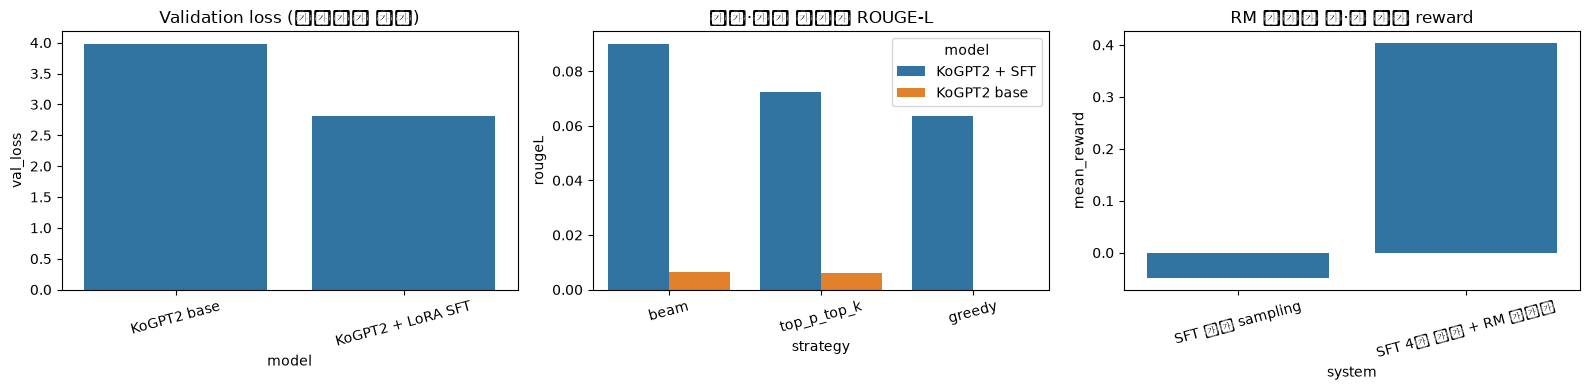

{'base_best_strategy': 'beam',
 'sft_best_strategy': 'beam',
 'rougeL_delta_sft_vs_base': 0.0835722773958068,
 'val_loss_delta_sft_vs_base': -1.1649335936496135,
 'rm_pair_accuracy': 0.7272727272727273,
 'rm_rerank_reward_delta': 0.4519781172275543,
 'rm_rerank_rougeL_delta': 0.10119047619047619}

In [20]:
# [셀 설명] 핵심 지표를 그래프로 그리고 모델 개선 폭을 자동 계산한다.
# 실행값을 그대로 사용하므로 개선되지 않은 결과도 숨기지 않고 확인할 수 있다.
# loss, ROUGE-L, reward를 세 개의 패널에 나눠 시각화한다.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=loss_comparison, x="model", y="val_loss", ax=axes[0])
axes[0].set_title("Validation loss (낮을수록 좋음)")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=generation_metrics, x="strategy", y="rougeL", hue="model", ax=axes[1])
axes[1].set_title("모델·생성 전략별 ROUGE-L")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(data=rerank_metrics, x="system", y="mean_reward", ax=axes[2])
axes[2].set_title("RM 재정렬 전·후 평균 reward")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

# 모델별 최고 생성 전략을 선택해 SFT 개선 폭을 계산한다.
best_base = generation_metrics[generation_metrics.model == "KoGPT2 base"].sort_values("rougeL", ascending=False).iloc[0]
best_sft = generation_metrics[generation_metrics.model == "KoGPT2 + SFT"].sort_values("rougeL", ascending=False).iloc[0]
# 보고서에 바로 사용할 핵심 delta와 RM 정확도를 정리한다.
summary = {
    "base_best_strategy": best_base.strategy,
    "sft_best_strategy": best_sft.strategy,
    "rougeL_delta_sft_vs_base": float(best_sft.rougeL - best_base.rougeL),
    "val_loss_delta_sft_vs_base": float(sft_val_loss - base_val_loss),
    "rm_pair_accuracy": rm_accuracy,
    "rm_rerank_reward_delta": float(rerank_metrics.iloc[1].mean_reward - rerank_metrics.iloc[0].mean_reward),
    "rm_rerank_rougeL_delta": float(rerank_metrics.iloc[1].rougeL - rerank_metrics.iloc[0].rougeL),
}
summary

## 22. 결과 파일 저장

보고서에 표를 옮기기 쉽도록 모든 결과를 CSV와 JSON으로 남깁니다. 모델 가중치는 앞 단계에서 adapter 형태로 저장했어요.

In [21]:
# [셀 설명] 정제·학습·생성·RM 평가 결과를 재사용 가능한 파일로 저장한다.
# CSV는 엑셀 호환을 위해 utf-8-sig로, 요약 정보는 JSON으로 기록한다.
# 모든 산출물을 artifacts 폴더 아래에 모은다.
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
# 표 형태의 결과를 각각 의미가 분명한 CSV 파일로 저장한다.
cleaning_report.to_csv(artifact_dir / "data_cleaning_report.csv", index=False, encoding="utf-8-sig")
loss_comparison.to_csv(artifact_dir / "base_vs_sft_loss.csv", index=False, encoding="utf-8-sig")
generation_metrics.to_csv(artifact_dir / "generation_metrics.csv", index=False, encoding="utf-8-sig")
generation_outputs.to_csv(artifact_dir / "generation_outputs.csv", index=False, encoding="utf-8-sig")
rm_metrics.to_csv(artifact_dir / "rm_pair_metrics.csv", index=False, encoding="utf-8-sig")
rerank_metrics.to_csv(artifact_dir / "sft_vs_rm_rerank.csv", index=False, encoding="utf-8-sig")
rm_qualitative.to_csv(artifact_dir / "qualitative_examples.csv", index=False, encoding="utf-8-sig")
# 핵심 실험 요약은 구조를 보존할 수 있는 JSON으로 저장한다.
with open(artifact_dir / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("저장 완료:", sorted(str(p) for p in artifact_dir.iterdir()))

저장 완료: ['artifacts\\base_vs_sft_loss.csv', 'artifacts\\data_cleaning_report.csv', 'artifacts\\experiment_summary.json', 'artifacts\\generation_metrics.csv', 'artifacts\\generation_outputs.csv', 'artifacts\\kogpt2_reward_lora_best', 'artifacts\\kogpt2_sft_lora', 'artifacts\\kogpt2_sft_lora_best', 'artifacts\\qualitative_examples.csv', 'artifacts\\rm_checkpoints', 'artifacts\\rm_pair_metrics.csv', 'artifacts\\rm_training_history.csv', 'artifacts\\sft_checkpoints', 'artifacts\\sft_checkpoints_cuda_bs16_ga2_len256_seed42_v2', 'artifacts\\sft_vs_rm_rerank.csv']


# 코드 요약

이 프로젝트는 다음 순서로 성능 향상을 검증했습니다. RTX 3090에서는 CUDA FP16·TF32를 사용하며, SFT/RM은 최대 50 epoch와 patience 5 조기 종료로 학습됩니다. SFT는 실행 조건별 폴더에서 최근 5개와 best checkpoint를, RM은 epoch별 checkpoint와 best adapter를 저장합니다.

1. **데이터셋 정제·추가**: KoChatGPT 데이터에서 빈 값, URL/HTML, 길이 이상치, 중복을 제거하고 새 한국어 생활형 지시문을 추가했습니다. prompt 기준으로 split해 데이터 누수를 막았습니다.
2. **기존 KoGPT2 기준선**: SFT 전 validation loss/perplexity와 Greedy·Beam·Top-p/Top-k 생성 품질을 측정했습니다.
3. **LoRA-SFT**: 답변 부분에만 loss를 적용해 효율적으로 instruction tuning했습니다. 기존 모델과 SFT 모델을 ROUGE-L, chrF, Distinct-2, Repeat-3 및 실제 출력 예시로 비교했습니다.
4. **Pairwise RM**: 사람이 더 선호한 답의 reward가 높아지도록 학습하고, 별도 test prompt에서 pair accuracy와 margin을 측정했습니다.
5. **SFT vs SFT+RM**: SFT 후보 4개를 RM으로 재정렬해 reward뿐 아니라 reference 기반 지표와 실제 문장까지 함께 비교했습니다.

## 회고

- 샘플 코드의 가장 큰 문제는 오래된 전용 라이브러리 의존성과 GPU 고정 코드, 그리고 RM을 생성 모델처럼 다룬 점이었습니다. 이를 표준 Transformers·PEFT 코드와 장치 독립 코드로 바꿨습니다.
- 이번 실험의 장점은 같은 test 질문과 생성 길이를 유지해 **모델 변경 효과와 decoding 효과를 분리**했다는 점입니다. 또한 수치를 미리 가정하지 않고 실행 결과의 delta를 그대로 저장합니다.
- ROUGE-L과 chrF는 참고 답안과 표현이 다르면 좋은 답도 낮게 평가할 수 있습니다. 반대로 RM reward는 학습된 선호의 편향을 그대로 반영할 수 있으므로 정성 평가를 함께 봐야 합니다.
- 직접 추가한 데이터가 작아 “새 데이터만의 효과”를 강하게 주장하기는 어렵습니다. 다음 실험에서는 `기존 정제 데이터만`과 `기존+신규 데이터`를 같은 seed로 각각 학습하는 ablation을 추가하고, 신규 데이터를 500개 이상으로 확대하는 것이 좋습니다.
- RM test accuracy가 0.5 근처라면 재정렬 결과를 신뢰하면 안 됩니다. 이때는 선호쌍 수를 늘리고, prompt 단위 split을 유지한 채 epoch·learning rate를 다시 탐색해야 합니다.
- 최종 결론은 위 `summary`의 실제 값으로 작성해야 합니다. 특히 SFT의 ROUGE-L 증가, validation loss 감소, RM pair accuracy 0.5 초과, 재정렬 후 reward와 reference 지표의 동반 개선 여부를 각각 구분해 보고하는 것이 정직합니다.